In [73]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch import autograd
from scipy.integrate import quad
import torch.optim as optim

In [74]:
# domain and resolution
x_min, x_max = -6.0, 6.0
n_points = 1000

x_grid = torch.linspace(x_min, x_max, n_points).reshape(-1, 1)
x_grid.requires_grad_(True)

dx = x_grid[1, 0] - x_grid[0, 0]   # uniform spacing, needed for trapz/Riemann sums


In [75]:
class Psi(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x):
        return self.net(x)


def energy(psi, psi_prime, x):
    integrand1 = (1/2) * psi_prime.conj() * psi_prime + (1/2)*psi**2 * x**2
    integrand2 = psi.conj() * psi
    int1 = torch.trapz(integrand1.squeeze(), x.squeeze())
    int2 = torch.trapz(integrand2.squeeze(), x.squeeze())
    # dx = 0.01
    # int1 = torch.sum(integrand1) * dx
    # int2 = torch.sum(integrand2) * dx
    return int1/int2




In [76]:
print(np.__version__)
print(torch.__version__)

2.0.1
2.4.0


In [77]:
model = Psi()

In [78]:
n_steps = 500
losses = []
psi_exact = torch.exp(- x_grid**2 / 2) / (np.pi**(1/4))
opt = optim.Adam(model.parameters(), lr=0.1)
for step in range(n_steps):
    opt.zero_grad()
    psi = model(x_grid)
    norm = torch.trapz((psi.conj() * psi).squeeze(), x_grid.squeeze())
    psi_normalized = psi / torch.sqrt(norm)
    psi_prime = autograd.grad(psi, x_grid, grad_outputs=torch.ones_like(psi), create_graph=True)[0]
    loss = energy(psi, psi_prime, x_grid)
    loss.backward()
    opt.step()

    losses.append(loss.item())
    if step % 100 == 0:
        print(f"step {step:4d}  E = {loss.item():.6f}")
        integrand = psi_normalized.conj() * psi_exact
        comp = torch.trapz(integrand.squeeze(), x_grid.squeeze())
        print(f"step {step:4d}  <psi|psi_exact> = {comp.item():.6f}")


step    0  E = 7.479850
step    0  <psi|psi_exact> = 0.386328
step  100  E = 0.500146
step  100  <psi|psi_exact> = 0.999998
step  200  E = 0.500034
step  200  <psi|psi_exact> = 1.000000
step  300  E = 0.500016
step  300  <psi|psi_exact> = 1.000000
step  400  E = 0.500010
step  400  <psi|psi_exact> = 1.000000


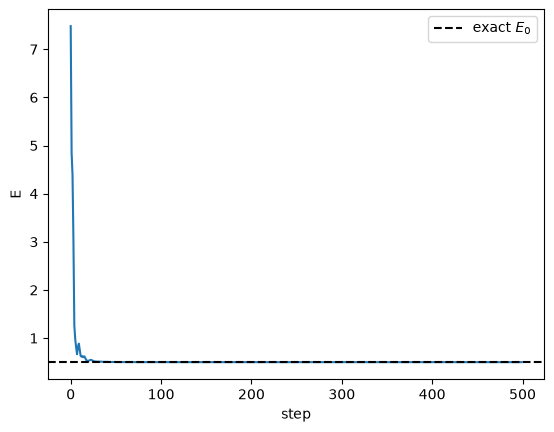

In [79]:
plt.plot(losses)
plt.axhline(0.5, color='k', linestyle='--', label='exact $E_0$')
plt.xlabel('step'); plt.ylabel('E'); plt.legend()
